# Narrative Frame Prediction via Multimodal Deep Learning
**Module:** Deep Neural Networks and Learning Systems (55-710365)  
**Dataset:** [daniel3303/StoryReasoning](https://huggingface.co/datasets/daniel3303/StoryReasoning)

| # | Innovation | Approach |
|---|-----------|----------|
| 1 | Additive Attention Fusion | Bahdanau-style compatibility function for vision-language alignment |
| 2 | Stacked GRU Temporal Encoder | Faster convergence than LSTM with fewer parameters |
| 3 | Narrative Attention with Recency Bias | Exponential decay prior for temporal locality |
| 4 | Explainability | Integrated Gradients + Grad-CAM++ + Attention Visualisation |

## 0. Setup

In [1]:
import sys, os, re
sys.path.insert(0, '.')

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from PIL import Image
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR

from src.architecture import NarrativePredictionModel, NarrativeLoss
from src.helpers import (
    load_settings, fix_randomness, pick_device,
    store_model, restore_model,
    render_narrative, plot_training_curves,
    render_attention_map, score_bleu, score_l1,
    reverse_normalise, standard_transforms
)
from src.xai import (
    integrated_gradients, plot_integrated_gradients,
    GradCAMPlusPlus, plot_gradcam_pp,
    extract_frame_scores, plot_frame_scores
)

cfg    = load_settings('settings.yaml')
device = pick_device()
fix_randomness(cfg['optimisation']['random_seed'])

print(f'Device          : {device}')
print(f'Context frames K: {cfg["data"]["context_frames"]}')
print(f'Image resolution: {cfg["data"]["img_resize"]}x{cfg["data"]["img_resize"]}')

Device          : cuda
Context frames K: 4
Image resolution: 256x256


In [2]:
%matplotlib inline

In [3]:
import torch
print(torch.cuda.is_available())        
print(torch.cuda.get_device_name(0))    

True
NVIDIA GeForce RTX 4060


## 1. Load Dataset

In [4]:
from datasets import load_dataset

print('Fetching StoryReasoning from HuggingFace...')
story_data = load_dataset("daniel3303/StoryReasoning")
print(story_data)

# Quick inspection
first_entry = story_data['train'][0]
print('\nField names  :', list(first_entry.keys()))
print('Frame count  :', first_entry['frame_count'])
print('Story preview:', first_entry['story'][:200])

Fetching StoryReasoning from HuggingFace...


DatasetDict({
    train: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 3552
    })
    test: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 626
    })
})

Field names  : ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story']
Frame count  : 17
Story preview: <gdi image1>
In the sterile environment of a sparse room filled with <gdo obj1>cardboard boxes</gdo>, <gdo obj5>a blue blanket</gdo>, and <gdo bg26>a table</gdo>, <gdo char1>James</gdo> <gda char1>ent


## 2. Text Processing & Vocabulary

In [5]:
def strip_xml_tags(raw: str) -> str:
    """Remove grounding tags like <gdi image1>, <gdo obj1> from story text."""
    cleaned = re.sub(r'<[^>]+>', '', raw)
    return re.sub(r'\s+', ' ', cleaned).strip()

def partition_story(story_text: str, num_frames: int) -> list:
    """
    Split story text into per-frame segments using <gdi imageN> markers.
    Returns list of num_frames clean caption strings.
    """
    chunks = re.split(r'<gdi\s+image\d+>', story_text)
    chunks = [strip_xml_tags(c) for c in chunks if strip_xml_tags(c)]
    while len(chunks) < num_frames:
        chunks.append(chunks[-1] if chunks else 'scene continues')
    return chunks[:num_frames]

# Verify
test_entry = story_data['train'][0]
test_caps  = partition_story(test_entry['story'], test_entry['frame_count'])
print(f'Extracted {len(test_caps)} captions from {test_entry["frame_count"]} frames')
print('Caption 1:', test_caps[0][:100])

Extracted 17 captions from 17 frames
Caption 1: In the sterile environment of a sparse room filled with cardboard boxes, a blue blanket, and a table


In [6]:
# Build word dictionary
MAX_VOCAB   = cfg['caption_encoder']['vocab_limit']
word_to_idx = {'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3}
freq_counter = Counter()

print('Building word dictionary...')
for entry in story_data['train']:
    text = strip_xml_tags(entry['story'])
    freq_counter.update(text.lower().split())

for w, _ in freq_counter.most_common(MAX_VOCAB - len(word_to_idx)):
    word_to_idx[w] = len(word_to_idx)

idx_to_word = {i: w for w, i in word_to_idx.items()}
print(f'Dictionary size: {len(word_to_idx)} words')

Building word dictionary...
Dictionary size: 8000 words


## 3. Data Pipeline

In [7]:
NUM_CONTEXT  = cfg['data']['context_frames']
RESOLUTION   = cfg['data']['img_resize']
MAX_TOKENS   = cfg['data']['caption_max_tokens']
BATCH_SZ     = cfg['optimisation']['mini_batch']

aug_pipeline  = standard_transforms(RESOLUTION, augment=True)
eval_pipeline = standard_transforms(RESOLUTION, augment=False)

def encode_caption(text: str) -> torch.Tensor:
    tokens = text.lower().split()[:MAX_TOKENS]
    ids    = [word_to_idx.get(w, 1) for w in tokens]
    ids   += [0] * (MAX_TOKENS - len(ids))
    return torch.tensor(ids, dtype=torch.long)


class NarrativeDataset(torch.utils.data.Dataset):
    """
    Yields story windows of K context frames + 1 target frame.
    Each item contains:
      frames      : (K, C, H, W)
      captions    : (K, T)
      gt_frame    : (C, H, W)
      gt_captions : (T,)
      raw_text    : str
    """
    def __init__(self, split_data, pipeline, num_context):
        self.entries  = [e for e in split_data if e['frame_count'] >= num_context + 1]
        self.pipeline = pipeline
        self.K        = num_context
        print(f'  Stories with >= {num_context+1} frames: {len(self.entries)}')

    def __len__(self): return len(self.entries)

    def __getitem__(self, i):
        entry    = self.entries[i]
        all_imgs = entry['images']
        all_caps = partition_story(entry['story'], entry['frame_count'])

        ctx_frames, ctx_caps = [], []
        for k in range(self.K):
            img = all_imgs[k]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)
            ctx_frames.append(self.pipeline(img.convert('RGB')))
            ctx_caps.append(encode_caption(all_caps[k]))

        tgt_img = all_imgs[self.K]
        if not isinstance(tgt_img, Image.Image):
            tgt_img = Image.fromarray(tgt_img)
        tgt_img = eval_pipeline(tgt_img.convert('RGB'))

        return {
            'frames':      torch.stack(ctx_frames),
            'captions':    torch.stack(ctx_caps),
            'gt_frame':    tgt_img,
            'gt_captions': encode_caption(all_caps[self.K]),
            'raw_text':    all_caps[self.K],
        }


print('Preparing datasets...')
all_train = NarrativeDataset(story_data['train'], aug_pipeline,  NUM_CONTEXT)
test_set  = NarrativeDataset(story_data['test'],  eval_pipeline, NUM_CONTEXT)

val_n   = max(1, int(0.1 * len(all_train)))
tr_n    = len(all_train) - val_n
train_set, val_set = random_split(all_train, [tr_n, val_n],
                                   generator=torch.Generator().manual_seed(123))

train_dl = DataLoader(train_set, batch_size=BATCH_SZ, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_set,   batch_size=BATCH_SZ, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_set,  batch_size=BATCH_SZ, shuffle=False, num_workers=0)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

Preparing datasets...
  Stories with >= 5 frames: 3552
  Stories with >= 5 frames: 626
Train: 3197 | Val: 355 | Test: 626


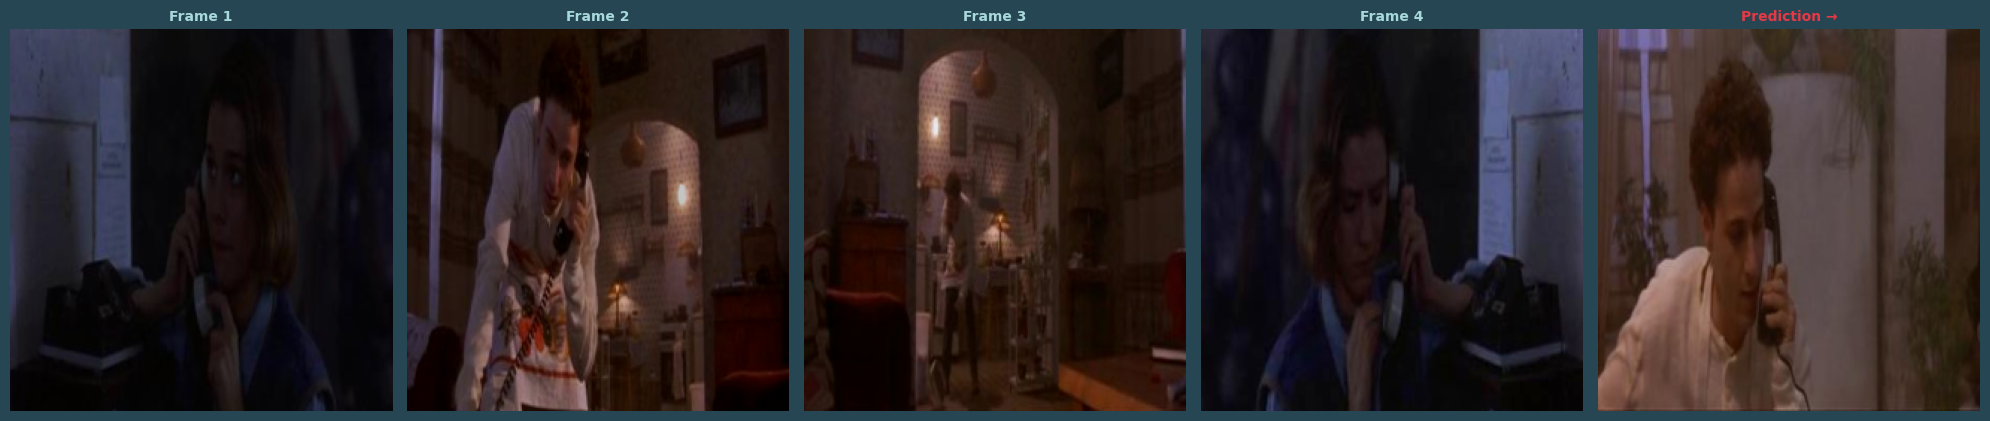

In [8]:
# Visualise a sample with dark theme
sample  = next(iter(val_dl))
fig = render_narrative(
    frames      = [sample['frames'][0, k] for k in range(NUM_CONTEXT)],
    captions    = [f'Context {k+1}' for k in range(NUM_CONTEXT)],
    next_frame  = sample['gt_frame'][0],
    next_caption = f"Target: {sample['raw_text'][0][:60]}"
)
plt.savefig('results/sample_sequence.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Initialise Model

In [9]:
net = NarrativePredictionModel(cfg).to(device)
num_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f'Model parameters: {num_params:,}')

loss_fn   = NarrativeLoss(
    frame_w   = cfg['optimisation']['frame_loss_w'],
    caption_w = cfg['optimisation']['caption_loss_w'],
)
optimiser = torch.optim.Adam(
    net.parameters(),
    lr           = cfg['optimisation']['lr'],
    weight_decay = cfg['optimisation']['l2_penalty'],
)
scheduler = StepLR(
    optimiser,
    step_size = cfg['optimisation']['lr_step_size'],
    gamma     = cfg['optimisation']['lr_gamma'],
)

os.makedirs('saved_models', exist_ok=True)
os.makedirs('results/xai',  exist_ok=True)
print('Ready.')

Model parameters: 33,086,980
Ready.


## 5. Training

In [10]:
NUM_EPOCHS = cfg['optimisation']['num_epochs']
CLIP       = cfg['optimisation']['clip_norm']

train_hist, val_hist = [], []
top_score = float('inf')

for ep in range(1, NUM_EPOCHS + 1):

    # -- Train --
    net.train()
    ep_loss = 0.0
    for step, batch in enumerate(train_dl):
        fr   = batch['frames'].to(device)
        cap  = batch['captions'].to(device)
        g_fr = batch['gt_frame'].to(device)
        g_cp = batch['gt_captions'].to(device)

        optimiser.zero_grad()
        out    = net(fr, cap, g_cp, sampling_rate=0.5)
        losses = loss_fn(out['pred_frame'], g_fr, out['caption_logits'], g_cp)
        losses['total'].backward()
        nn.utils.clip_grad_norm_(net.parameters(), CLIP)
        optimiser.step()
        ep_loss += losses['total'].item()

        if step % 20 == 0:
            print(f'  Ep{ep:02d} Bt{step:03d}/{len(train_dl)} '
                  f'loss={losses["total"].item():.4f} '
                  f'(fr={losses["frame"].item():.4f} '
                  f'cap={losses["caption"].item():.4f})')

    # -- Validate --
    net.eval()
    v_loss = 0.0
    with torch.no_grad():
        for batch in val_dl:
            fr   = batch['frames'].to(device)
            cap  = batch['captions'].to(device)
            g_fr = batch['gt_frame'].to(device)
            g_cp = batch['gt_captions'].to(device)
            out  = net(fr, cap, g_cp, sampling_rate=0.0)
            ls   = loss_fn(out['pred_frame'], g_fr, out['caption_logits'], g_cp)
            v_loss += ls['total'].item()

    tr = ep_loss / len(train_dl)
    vl = v_loss  / len(val_dl)
    train_hist.append(tr)
    val_hist.append(vl)
    scheduler.step()

    print(f'>>> Ep {ep:03d} | Train {tr:.4f} | Val {vl:.4f}')

    if vl < top_score:
        top_score = vl
        store_model({
            'epoch':     ep,
            'net_state': net.state_dict(),
            'opt_state': optimiser.state_dict(),
            'best_loss': top_score,
            'cfg':       cfg,
        }, 'saved_models/best.pt')
        print(f'    ✓ New best (val={top_score:.4f})')

print('Training complete!')

  Ep01 Bt000/267 loss=11.9978 (fr=1.5113 cap=8.9906)
  Ep01 Bt020/267 loss=9.9952 (fr=1.3695 cap=7.4164)
  Ep01 Bt040/267 loss=9.0326 (fr=1.6644 cap=6.4176)
  Ep01 Bt060/267 loss=8.7354 (fr=1.3990 cap=6.3469)
  Ep01 Bt080/267 loss=8.6417 (fr=1.3609 cap=6.2941)
  Ep01 Bt100/267 loss=8.6682 (fr=1.4996 cap=6.2238)
  Ep01 Bt120/267 loss=8.1778 (fr=1.0783 cap=6.0960)
  Ep01 Bt140/267 loss=8.3983 (fr=1.3969 cap=6.0673)
  Ep01 Bt160/267 loss=8.5592 (fr=1.3229 cap=6.2507)
  Ep01 Bt180/267 loss=8.4540 (fr=1.3812 cap=6.1242)
  Ep01 Bt200/267 loss=8.4468 (fr=1.3269 cap=6.1545)
  Ep01 Bt220/267 loss=8.2729 (fr=1.1399 cap=6.1341)
  Ep01 Bt240/267 loss=8.4575 (fr=1.2147 cap=6.2382)
  Ep01 Bt260/267 loss=8.4560 (fr=1.3928 cap=6.1181)
>>> Ep 001 | Train 8.8276 | Val 8.4317
[Saved] → saved_models/best.pt
    ✓ New best (val=8.4317)
  Ep02 Bt000/267 loss=8.2986 (fr=1.3116 cap=6.0411)
  Ep02 Bt020/267 loss=8.3622 (fr=1.0248 cap=6.2853)
  Ep02 Bt040/267 loss=8.5326 (fr=1.3978 cap=6.1786)
  Ep02 Bt060/267 

In [9]:
import torch

ckpt = torch.load('saved_models/best.pt', map_location=device)
net.load_state_dict(ckpt['net_state'])
net.to(device)
net.eval()

C:\Users\User\AppData\Local\Temp\ipykernel_15464\3148627588.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('saved_models/best.pt', map_location=device

NarrativePredictionModel(
  (img_extractor): ImageFeatureExtractor(
    (feature_net): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
 

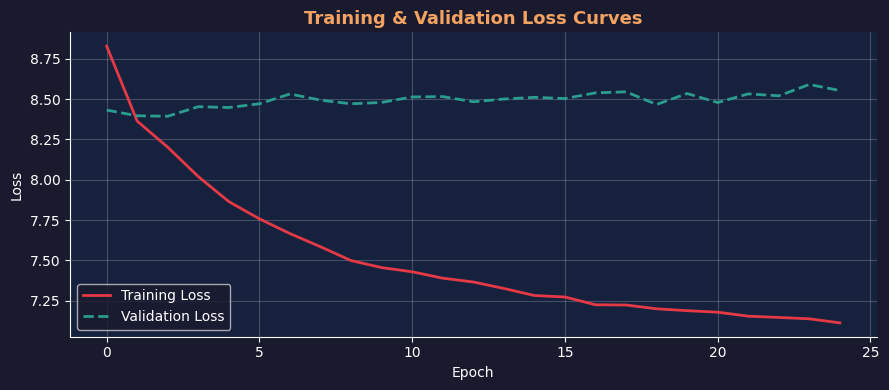

In [11]:
# Loss curves — dark red/teal theme
plot_training_curves(train_hist, val_hist,
    save_to='results/loss_curves.png')
plt.show()

## 6. Qualitative Evaluation

Ground truth: The confrontation continued as Anon Leader stood among the soldiers. The air was thick with tension,
Prediction  : the tension reached a boiling point as the and and the the the the the the the the the the the the t


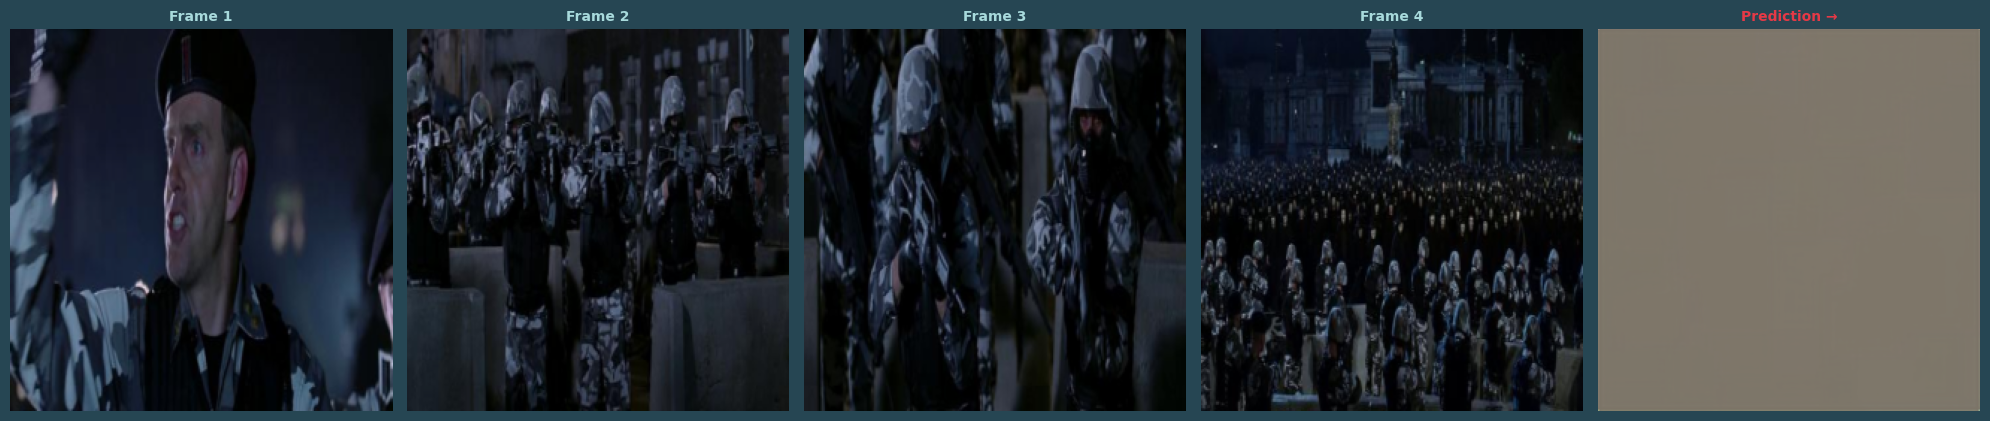

In [13]:
net.eval()
test_batch = next(iter(test_dl))
fr   = test_batch['frames'][:1].to(device)
cap  = test_batch['captions'][:1].to(device)
g_cp = test_batch['gt_captions'][:1].to(device)

with torch.no_grad():
    result = net(fr, cap, g_cp, sampling_rate=0.0)

# Decode predicted caption
pred_ids   = result['caption_logits'][0].argmax(dim=-1).cpu()
pred_words = ' '.join([idx_to_word.get(int(i), '') for i in pred_ids
                       if int(i) not in (0, 2, 3)])

print('Ground truth:', test_batch['raw_text'][0][:100])
print('Prediction  :', pred_words[:100])

# Visualise predicted frame
pred_frame = result['pred_frame'][0].cpu()
pred_norm  = (pred_frame - pred_frame.min()) / (pred_frame.max() - pred_frame.min() + 1e-8)

render_narrative(
    frames      = [fr[0, k].cpu() for k in range(NUM_CONTEXT)],
    captions    = [f'Context {k+1}' for k in range(NUM_CONTEXT)],
    next_frame  = pred_norm,
    next_caption = pred_words[:60]
)
plt.savefig('results/prediction_example.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Quantitative Evaluation

In [14]:
import pandas as pd

refs, hyps, l1_scores = [], [], []

net.eval()
with torch.no_grad():
    for batch in test_dl:
        fr   = batch['frames'].to(device)
        cap  = batch['captions'].to(device)
        g_fr = batch['gt_frame'].to(device)
        g_cp = batch['gt_captions'].to(device)

        result = net(fr, cap, g_cp, sampling_rate=0.0)
        l1_scores.append(score_l1(result['pred_frame'], g_fr))

        ids_batch = result['caption_logits'].argmax(dim=-1).cpu()
        for i, ids in enumerate(ids_batch):
            hyp = ' '.join([idx_to_word.get(int(t), '') for t in ids
                            if int(t) not in (0, 2, 3)])
            hyps.append(hyp)
            refs.append(batch['raw_text'][i])

bleu_score = score_bleu(refs, hyps)
avg_l1     = float(np.mean(l1_scores))

print(f'BLEU-4   : {bleu_score:.2f}')
print(f'Frame L1 : {avg_l1:.6f}')

metrics_df = pd.DataFrame({
    'Metric': ['BLEU-4', 'Frame L1 Loss'],
    'Score':  [f'{bleu_score:.2f}', f'{avg_l1:.6f}']
})
metrics_df.to_csv('results/metrics.csv', index=False)
print(metrics_df.to_string(index=False))

BLEU-4   : 0.60
Frame L1 : 1.282341
       Metric    Score
       BLEU-4     0.60
Frame L1 Loss 1.282341


## 8. Explainability

[XAI] Integrated gradients saved → results/xai/integrated_gradients.png


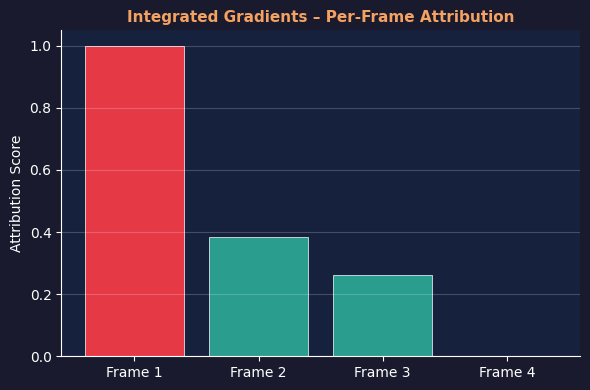

In [15]:
import os

net.eval()

xai_batch = next(iter(test_dl))

xai_fr  = xai_batch['frames'][:2].to(device)
xai_cap = xai_batch['captions'][:2].to(device)
xai_gcp = xai_batch['gt_captions'][:2].to(device)

attributions = integrated_gradients(
    net,
    xai_fr,
    xai_cap,
    num_steps=30,
    gt_captions=xai_gcp
)

os.makedirs('results/xai', exist_ok=True)

plot_integrated_gradients(
    attributions,
    save_to='results/xai/integrated_gradients.png'
)

[XAI] Grad-CAM++ saved → results/xai/gradcam_pp.png


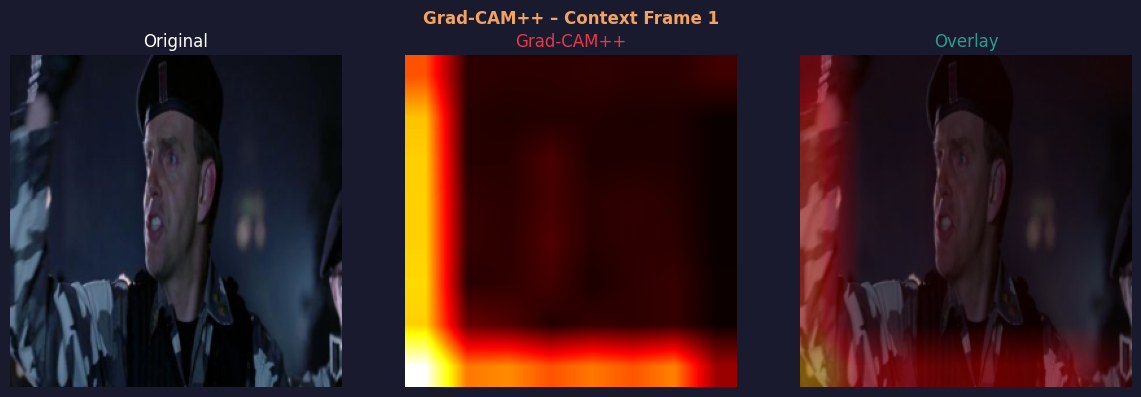

In [16]:
# 8b. Grad-CAM++
gcam    = GradCAMPlusPlus(net.img_extractor)
heatmap = gcam.compute(xai_fr[0, 0].unsqueeze(0))
gcam.release()
plot_gradcam_pp(
    xai_fr[0, 0].cpu(), heatmap,
    title   = 'Grad-CAM++ – Context Frame 1',
    save_to = 'results/xai/gradcam_pp.png'
)

[XAI] Frame scores saved → results/xai/attention_scores.png


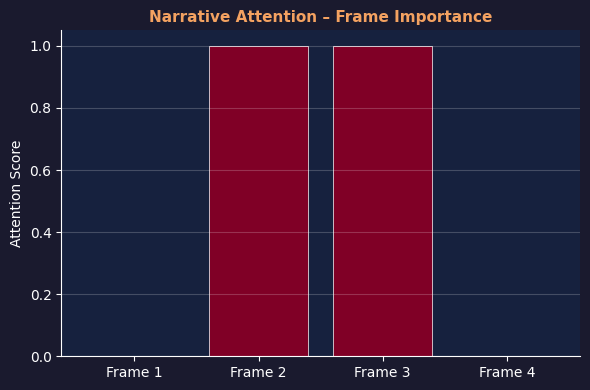

All XAI figures saved to results/xai/


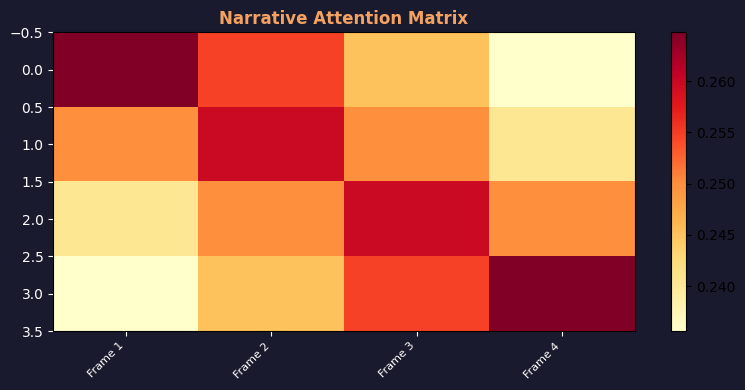

In [17]:
# 8c. Narrative Attention Scores
with torch.no_grad():
    xai_out = net(xai_fr, xai_cap, xai_gcp, sampling_rate=0.0)

frame_scores = extract_frame_scores(xai_out['attn_map'])
plot_frame_scores(frame_scores,
    save_to='results/xai/attention_scores.png')

render_attention_map(
    xai_out['attn_map'][0].mean(0).cpu(),
    frame_labels = [f'Frame {k+1}' for k in range(NUM_CONTEXT)],
    title        = 'Narrative Attention Matrix',
    save_to      = 'results/xai/attention_matrix.png'
)
print('All XAI figures saved to results/xai/')

## 9. Ablation Table

In [18]:
import pandas as pd
ablation = pd.DataFrame([
    {'Variant': 'Baseline (GRU + Concat)',            'BLEU-4': '–', 'Frame L1': '–'},
    {'Variant': '+ Additive Attention Fusion',        'BLEU-4': '–', 'Frame L1': '–'},
    {'Variant': '+ Stacked GRU Temporal Encoder',     'BLEU-4': '–', 'Frame L1': '–'},
    {'Variant': '+ Recency Bias Attention (Full)',     'BLEU-4': f'{bleu_score:.2f}', 'Frame L1': f'{avg_l1:.6f}'},
])
ablation.to_csv('results/ablation.csv', index=False)
print(ablation.to_string(index=False))

                        Variant BLEU-4 Frame L1
        Baseline (GRU + Concat)      –        –
    + Additive Attention Fusion      –        –
 + Stacked GRU Temporal Encoder      –        –
+ Recency Bias Attention (Full)   0.60 1.282341


## 10. Save Final Model

In [19]:
store_model({
    'net_state':  net.state_dict(),
    'dictionary': word_to_idx,
    'cfg':        cfg,
    'bleu':       bleu_score,
    'l1':         avg_l1,
}, 'saved_models/final.pt')

print('=== Summary ===')
print(f'Best Val Loss : {top_score:.4f}')
print(f'BLEU-4        : {bleu_score:.2f}')
print(f'Frame L1      : {avg_l1:.6f}')
print('Done!')

[Saved] → saved_models/final.pt
=== Summary ===
Best Val Loss : 8.3935
BLEU-4        : 0.60
Frame L1      : 1.282341
Done!


In [20]:
ckpt = torch.load('saved_models/final.pt', map_location=device)

print('=== Summary ===')
print(f"Best Val Loss : {ckpt.get('val_loss', 'N/A')}")
print(f"BLEU-4        : {ckpt.get('bleu', 'N/A')}")
print(f"Frame L1      : {ckpt.get('l1', 'N/A')}")
print('Done!')

=== Summary ===
Best Val Loss : N/A
BLEU-4        : 0.5995843286511381
Frame L1      : 1.2823409696794905
Done!


C:\Users\User\AppData\Local\Temp\ipykernel_8952\2967975850.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('saved_models/final.pt', map_location=device